# 95662 - Introduction to Machine Learning
##### By: Brenno, Camilla, Kok Soon

## 0. Config and Imports

In [1]:
import os
from pathlib import Path
import json
import pandas as pd
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [3]:
# Fixing seed to remove randomness, for better comparisons
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

### A. Local Setup

In [4]:
# DATA_DIR = Path('./data')# Path to dataset

### B. Colab Setup

In [5]:
!pip -q install gdown

DATA_DIR = Path("/content/ML_Exam_Project")
DATA_DIR.mkdir(exist_ok=True)

FOLDER_URL = "https://drive.google.com/drive/folders/17Cklb8rQ2DJt_NoWPCbgqkd16V1MOXiw?usp=sharing"

!gdown --folder "$FOLDER_URL" -O "$DATA_DIR"

Retrieving folder contents
Processing file 1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2 test_id.jsonl
Processing file 1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s test_long.jsonl
Processing file 17YHqluGDYL1izzYFYWON5FzDZZaCcist test_ood.jsonl
Processing file 19yevHfLO23hJ9UEs31F0wa0I9YwESMqP train_augmented.jsonl
Processing file 1uZ9iQSPtoYhlb1Kt2jCigoFePQGsgLRb train.jsonl
Processing file 1vt1B-Optfa19JqtnNSOuL5Ao7tq1ySap validation_augmented.jsonl
Processing file 1knh_LSuwKqZeUn5cbFJ9bfnu03iYQKJ0 validation.jsonl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1mxYncZ-k5CJVcaMHjpEtsp79OSXVrSR2
To: /content/ML_Exam_Project/test_id.jsonl
100% 222k/222k [00:00<00:00, 40.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1utlrU9pwh-Ou1LomUKtZXaB6HemPzI9s
To: /content/ML_Exam_Project/test_long.jsonl
100% 182k/182k [00:00<00:00, 92.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=17YHq

## 1. Data

### 1.1 File Sanity Check

In [6]:
expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
    "train_augmented.jsonl",
    "validation_augmented.jsonl"
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - /content/ML_Exam_Project/train.jsonl
 - /content/ML_Exam_Project/validation.jsonl
 - /content/ML_Exam_Project/test_id.jsonl
 - /content/ML_Exam_Project/test_ood.jsonl
 - /content/ML_Exam_Project/test_long.jsonl
 - /content/ML_Exam_Project/train_augmented.jsonl
 - /content/ML_Exam_Project/validation_augmented.jsonl


### 1.2 Data Loading

In [7]:
# Function to load jsonl into pandas df object
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [8]:
train_df = load_jsonl(DATA_DIR / "train.jsonl")
train_augmented_df = load_jsonl(DATA_DIR / "train_augmented.jsonl")
validation_df = load_jsonl(DATA_DIR / "validation.jsonl")
validation_augmented_df = load_jsonl(DATA_DIR / "validation_augmented.jsonl")
test_id_df = load_jsonl(DATA_DIR / "test_id.jsonl")
test_ood_df = load_jsonl(DATA_DIR / "test_ood.jsonl")
test_long_df = load_jsonl(DATA_DIR / "test_long.jsonl")

### 1.3 Understanding Data

#### 1.3.1 Data shapes

In [9]:
print("Train:", train_df.shape)
print("Train Augmented:", train_augmented_df.shape)
print("Validation:", validation_df.shape)
print("Validation Augmented:", validation_augmented_df.shape)
print("Test ID:", test_id_df.shape)
print("Test OOD:", test_ood_df.shape)
print("Test long:", test_long_df.shape)

Train: (12000, 6)
Train Augmented: (12000, 6)
Validation: (2000, 6)
Validation Augmented: (2000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


#### 1.3.2 Data Example

In [10]:
train_df.head()

,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


#### 1.3.3 Test for White Space

It is important to test for white spaces to know if it is required to strip them away because whitespaces such as (1 + 1 3) is a wrong mathematical expression. Furthermore, our plan to use a binary tree to linearize mathematical expression may run into issues if we use whitespace to separate terms

In [11]:
def check_for_whitespace(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    return combined_df["expression"].astype(str).str.contains(r"\s").any()

In [12]:
print("White Space Exist") if check_for_whitespace(train_df,validation_df,train_augmented_df,validation_augmented_df,test_id_df,test_ood_df,test_long_df) else print("No Whitespace found")

No Whitespace found


#### 1.3.4 Test for Unary Operators

Unary operators like -5 have to be considered when constructing expression trees, if unary operators exist, we have to preprocess our data in a way where the sign and the number are interpreted as one (i.e. "-5" instead of "- 5")

In [13]:
def check_for_unary_operators(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    def has_unary(expr):
        for i, ch in enumerate(expr):
            if ch in "+-":
                if i == 0:
                    return True  # starts with + or -
                prev = expr[i - 1]
                if prev in "(-+":
                    return True
        return False

    return combined_df["expression"].apply(has_unary).any()

In [14]:
print("Unary Operator Exist") if check_for_unary_operators(train_df,validation_df,train_augmented_df,validation_augmented_df,test_id_df,test_ood_df,test_long_df) else print("No Unary Operator found")

No Unary Operator found


#### 1.3.5 Data Preprocessing and Transformation

In this step, we aim to represent our input data in a different form in an attempt to help our models learn better

##### 1.3.5.1 ExpressionTree, Prefix, Postfix

In [15]:
# Node Structure (Intermediary structure required to build trees)
class Node:
    def __init__(self, value, left=None, right=None):
        self.value = value
        self.left = left
        self.right = right

In [16]:
# ExpressionTree Class (class used to represent mathematical expression)
class ExpressionTree:
    def __init__(self, root_node):
        self.root_node = root_node

    def get_root_node(self):
        return self.root_node

    def to_postfix(self):
        def dfs(node):
            if node is None:
                return []
            return dfs(node.left) + dfs(node.right) + [str(node.value)]

        return " ".join(dfs(self.root_node))

    def to_prefix(self):
        def dfs(node):
            if node is None:
                return []
            return [str(node.value)] + dfs(node.left) + dfs(node.right)

        return " ".join(dfs(self.root_node))

    def get_depth(self):
        def dfs(node, current_depth):
            if node is None:
                return current_depth - 1

            left_depth = dfs(node.left, current_depth + 1)
            right_depth = dfs(node.right, current_depth + 1)

            return max(left_depth, right_depth)

        if self.root_node is None:
            return 0

        return dfs(self.root_node, 1)

    def get_operator_count(self):
        operators = "+-"

        def dfs(node):
            if node is None:
                return 0

            count = 1 if str(node.value) in operators else 0

            count += dfs(node.left)
            count += dfs(node.right)

            return count

        return dfs(self.root_node)

In [17]:
def reduce(operator_stack, operand_stack):
    op = operator_stack.pop()

    right = operand_stack.pop()
    left = operand_stack.pop()

    operand_stack.append(Node(op, left, right))


def build_tree_with_expression(expression):
    subtree_stack = []
    operator_stack = []

    for ch in expression:

        if ch.isnumeric():
            subtree_stack.append(Node(ch))

        elif ch == '(':
            operator_stack.append(ch)

        elif ch == ')':
            while operator_stack[-1] != '(':
                reduce(operator_stack, subtree_stack)

            operator_stack.pop()  # remove '('

        elif ch in '+-':

            while (
                operator_stack
                and operator_stack[-1] != '('
            ):
                reduce(operator_stack, subtree_stack)

            operator_stack.append(ch)

    while operator_stack:
        reduce(operator_stack, subtree_stack)

    root = subtree_stack.pop()
    return ExpressionTree(root)

expression = "5-(6-5)+8+8"
build_tree_with_expression(expression).to_postfix()

'5 6 5 - - 8 + 8 +'

##### 1.3.5.2 Target Value Normalization
Normalizing the target variable (output) can help improve model performance and stability during training, especially with regression tasks. By scaling the target values, the model can learn more efficiently. We will normalize `y_train` and `y_val` using the mean and standard deviation calculated from `y_train`.

In [18]:
# Calculate mean and standard deviation from training targets
y_mean = train_df["value"].mean()
y_std = train_df["value"].std()

print(f"Training target mean: {y_mean:.2f}")
print(f"Training target standard deviation: {y_std:.2f}")

Training target mean: 4.86
Training target standard deviation: 10.59


In [19]:
def normalize_target_value(value,mean,std):
    return (value - mean) / std

def denormalize_target_value(normalized_value, mean, std):
    return normalized_value * std + mean

#### 1.3.6 Applying Transformations

In this step, we apply the previously discussed preprocessing steps

In [20]:
def apply_transformation(df):
    df["normalized_value"] = df["value"].apply(lambda y: normalize_target_value(y, y_mean, y_std))
    df["prefix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_prefix())
    df["postfix"] = df["expression"].apply(lambda x: build_tree_with_expression(x).to_postfix())

    return df

In [21]:
train_df = apply_transformation(train_df)
train_augmented_df = apply_transformation(train_augmented_df)
validation_df = apply_transformation(validation_df)
validation_augmented_df = apply_transformation(validation_augmented_df)
test_id_df = apply_transformation(test_id_df)
test_ood_df = apply_transformation(test_ood_df)
test_long_df = apply_transformation(test_long_df)

train_df.head()

,id,expression,value,length,operator_count,depth,normalized_value,prefix,postfix
0,train-00000,4+4+7+3+8-1,25,11,5,5,1.901590,- + + + + 4 4 7 3 8 1,4 4 + 7 + 3 + 8 + 1 -
1,train-00001,5-(6-5)+8+8,20,11,4,5,1.429479,+ + - 5 - 6 5 8 8,5 6 5 - - 8 + 8 +
2,train-00002,5-3+1,3,5,2,3,-0.175696,+ - 5 3 1,5 3 - 1 +
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,-2.441825,- 1 + + + + 1 5 8 7 1,1 1 5 + 8 + 7 + 1 + -
4,train-00004,7+1-(6+5+9),-12,11,4,4,-1.592027,- + 7 1 + + 6 5 9,7 1 + 6 5 + 9 + -


#### 1.3.7 Summary of Data

Here, we create a function to give a summary of our data so we can compare the different data splits

In [22]:
# Function to return summary of data
# It is possible to calculate the summary of multiple data split together by passing them in together
def summary(*data_df):
    for i, df in enumerate(data_df, start=1):
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"Argument {i} is not a DataFrame")

    combined_df = pd.concat(data_df, ignore_index=True)

    result = pd.DataFrame({
        "mean": combined_df.mean(numeric_only=True),
        "min": combined_df.min(numeric_only=True),
        "max": combined_df.max(numeric_only=True),
    })

    # Expecting comparison of data split with different size, so we have to normalise for more meaningful comparison
    result.loc["value", "positive_ratio"] = (combined_df["value"] > 0).mean()
    result.loc["value", "negative_ratio"] = (combined_df["value"] < 0).mean()
    result.loc["value", "zero_ratio"] = (combined_df["value"] == 0).mean()

    mode = combined_df.mode(numeric_only=True).iloc[0]
    result["mode"] = mode

    return result

In [23]:
display(summary(train_df))
display(summary(train_augmented_df))
display(summary(validation_df))
display(summary(validation_augmented_df))
display(summary(test_id_df))
display(summary(test_ood_df))
display(summary(test_long_df))

,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.860750e+00,-36.000000,46.000000,0.65725,0.306167,0.036583,2.000000
length,9.607000e+00,5.000000,19.000000,NaN,NaN,NaN,7.000000
operator_count,3.489917e+00,2.000000,5.000000,NaN,NaN,NaN,4.000000
depth,3.689917e+00,3.000000,6.000000,NaN,NaN,NaN,4.000000
normalized_value,2.072416e-18,-3.858156,3.884453,NaN,NaN,NaN,-0.270118


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.863667,-36.000000,46.000000,0.657417,0.30625,0.036333,2.000000
length,9.621500,5.000000,33.000000,NaN,NaN,NaN,7.000000
operator_count,3.496250,2.000000,13.000000,NaN,NaN,NaN,4.000000
depth,4.012250,3.000000,11.000000,NaN,NaN,NaN,3.000000
normalized_value,0.000275,-3.858156,3.884453,NaN,NaN,NaN,-0.270118


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.585000,-32.000000,47.000000,0.64,0.323,0.037,4.000000
length,9.604000,5.000000,19.000000,NaN,NaN,NaN,7.000000
operator_count,3.497000,2.000000,5.000000,NaN,NaN,NaN,3.000000
depth,3.679000,3.000000,6.000000,NaN,NaN,NaN,3.000000
normalized_value,-0.026037,-3.480468,3.978875,NaN,NaN,NaN,-0.081274


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.104500,-31.000000,46.000000,0.6695,0.2995,0.031,7.000000
length,9.724000,5.000000,33.000000,NaN,NaN,NaN,7.000000
operator_count,3.541500,2.000000,13.000000,NaN,NaN,NaN,5.000000
depth,4.047500,3.000000,14.000000,NaN,NaN,NaN,3.000000
normalized_value,0.023015,-3.386046,3.884453,NaN,NaN,NaN,0.201992


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,5.232500,-29.000000,40.000000,0.668,0.296,0.036,8.000000
length,9.609000,5.000000,19.000000,NaN,NaN,NaN,7.000000
operator_count,3.487000,2.000000,5.000000,NaN,NaN,NaN,2.000000
depth,3.722000,3.000000,6.000000,NaN,NaN,NaN,4.000000
normalized_value,0.035101,-3.197202,3.317921,NaN,NaN,NaN,0.296414


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.855500,-38.000000,44.000000,0.638,0.332,0.03,5.000000
length,12.484000,7.000000,23.000000,NaN,NaN,NaN,9.000000
operator_count,4.515500,3.000000,6.000000,NaN,NaN,NaN,5.000000
depth,4.434500,3.000000,7.000000,NaN,NaN,NaN,4.000000
normalized_value,-0.000496,-4.047001,3.695609,NaN,NaN,NaN,0.013148


,mean,min,max,positive_ratio,negative_ratio,zero_ratio,mode
value,4.024667,-42.000000,51.000000,0.609333,0.362,0.028667,7.000000
length,17.744000,15.000000,27.000000,NaN,NaN,NaN,15.000000
operator_count,6.214667,5.000000,7.000000,NaN,NaN,NaN,7.000000
depth,5.500667,4.000000,8.000000,NaN,NaN,NaN,4.000000
normalized_value,-0.078945,-4.424689,4.356563,NaN,NaN,NaN,0.201992


#### 1.3.8 Helper Function for Plotting Loss Graph

In [24]:
def to_list(x):
    return [i.detach().cpu().item() if torch.is_tensor(i) else i for i in x]

def draw_loss_graph(epochs, train_losses, val_losses = None, val_losses_RMSE=None, val_losses_MAE=None):     #for the real training if we want to plot we don't have a validation set
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    if val_losses is not None:
        plt.plot(epochs, to_list(val_losses), label="Validation Loss", marker='o')       #useful for seeing eventual overfitting
        plt.plot(epochs, to_list(val_losses_RMSE), label="Root Mean Squared Error on the validation set", marker='o')
        plt.plot(epochs, to_list(val_losses_MAE), label="Mean Absolute Error on the validation set", marker='o')
    plt.xlabel("Epochs")
    plt.ylabel("Losses")
    plt.legend()
    plt.title("Loss Graph")

## 2. CNN Regression

### 2.1 Defining Input and Target (x and y)

In [25]:
combined_train_df = pd.concat([train_df,train_augmented_df], ignore_index=True)
combined_validation_df = pd.concat([validation_df,validation_augmented_df], ignore_index=True)

x_train = combined_train_df["expression"]
y_train = combined_train_df["value"]
x_val = combined_validation_df["expression"]
y_val = combined_validation_df["value"]

### 2.2 Tokenization

Identify all unique characters from expression to build a vocabulary

In [26]:
all_chars = set()
for expression in x_train:
    for char in expression:
        all_chars.add(char)


V = sorted(list(all_chars))
PAD_TOKEN = "[PAD]"
V = [PAD_TOKEN] + V + [" "]
print(len(V))
token_to_index = {token: i for i, token in enumerate(V)}
print(token_to_index)

16
{'[PAD]': 0, '(': 1, ')': 2, '+': 3, '-': 4, '0': 5, '1': 6, '2': 7, '3': 8, '4': 9, '5': 10, '6': 11, '7': 12, '8': 13, '9': 14, ' ': 15}


In [27]:
def encode(x):
    return [token_to_index[token] for token in list(x)]

def decode(x):
    return ''.join([V[index] for index in x if V[index] != PAD_TOKEN])

# Verify that index encoding is working as intended
print(encode('+'))
print(decode(encode('+')))

[3]
+


### 2.3 Batching and Transformation

We dynamically pad every batch that has to be given to the nn by the length of the maximum element in it. `batch` is a list of `(input_sequence, target_value)` tuples. For us, `input_sequence` is `x_data`, and `target_value` is `y_data`

In [28]:
def collate_fn(batch):
    # Separate inputs (expressions) and targets (values)
    expressions = [item[0] for item in batch]
    values = [item[1] for item in batch]

    # Encode expressions
    encoded_expressions = [encode(expr) for expr in expressions]

    # Find the maximum length in the current batch
    batch_max_length = max(len(seq) for seq in encoded_expressions)

    # Pad each sequence in the batch to batch_max_length
    padded_expressions = []
    for seq in encoded_expressions:
        padding_needed = batch_max_length - len(seq)
        padded_seq = seq + [token_to_index[PAD_TOKEN]] * padding_needed
        padded_expressions.append(padded_seq)

    # Convert to PyTorch tensors
    x_batch = torch.tensor(padded_expressions, dtype=torch.long)
    y_batch = torch.tensor(values, dtype=torch.float)

    return x_batch, y_batch

### 2.4 Model Definition

In [29]:
VOCAB_SIZE = len(V)
#EMBEDDING_DIM = 64 # Dimension for token embeddings
NUM_OUTPUTS = 1 # For regression, we predict a single value (the result of the expression)

class ExpressionCNNOneHot(nn.Module):                               #we are defining a new model to enable the dynamic padding of the inputs
    def __init__(self, vocab_size, hidden_channels=64, num_outputs=1):            #num_outputs is for classification against regression problems, 199 for classification, 1 for regression
        super(ExpressionCNNOneHot, self).__init__()                         #all the attributes of the nn.Module class, (we need to see it a little bit)

        self.conv1 = nn.Conv1d(                                         #in this type of model we add 2 convolution, both of size 3, the inputs of the first one have the vocab size as dimension, the outputs have dimension hidden_channels
            in_channels=vocab_size,
            out_channels=hidden_channels,
            kernel_size=3,
            padding=1                                                 #CONVOLUTIONAL padding
        )

        self.conv2 = nn.Conv1d(                                           #the inputs and the outputs of the of the second one have both the size of hidden_channels, we can change this
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv3 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            kernel_size=7,
            padding=3
        )

        self.conv4 = nn.Conv1d(
            in_channels=hidden_channels,
            out_channels=hidden_channels//2,
            kernel_size=5,
            padding=2
        )

       # self.conv5 = nn.Conv1d(
        #    in_channels=hidden_channels,
         #   out_channels=hidden_channels,
          #  kernel_size=3,
           # padding=1
       # )

        #self.conv6 = nn.Conv1d(
         #   in_channels=hidden_channels,
          #  out_channels=hidden_channels,
           # kernel_size=3,
            #padding=1
        #)

        #self.conv7 = nn.Conv1d(
         #   in_channels=hidden_channels,
          #  out_channels=hidden_channels,
           # kernel_size=3,
            #padding=1
        #)

#we can change the structure by make layers of different sizes, not only fixing one hidden dimension
        self.fc = nn.Linear(hidden_channels//2, num_outputs)                       #output function, if we use classification we have also to use softmax or directly argmax in the training (We have to check it)

    def forward(self, x, mask):
        # x shape: (batch_size, vocab_size, sequence_length)
        # mask shape: (batch_size, sequence_length)

#we should had a normalization of the parameters
        h = F.relu(self.conv1(x))                                                 #first layer with sigma = ReLU
        h = F.relu(self.conv2(h))                                                   #Second layer with sigma = ReLU, h is the output
        h = F.relu(self.conv3(h))
        h = F.relu(self.conv4(h))
        #h = F.relu(self.conv5(h))
        #h = F.relu(self.conv6(h))
        #h = F.relu(self.conv7(h))

# Masked mean pooling
# h shape: (batch_size, hidden_channels, sequence_length)

        #after applying the neural network, we need a way to obtain one vector instead of the whole expression, therefore masked mean pooling (mean pooling but we don't count PAD tokens)
        #mask will be a tensor of the same shame as the input sequence, an element in this tensor can be 1, if the corresponding term of the sequence is not PAD, and 0, if it is PAD

        mask = mask.unsqueeze(1)  # (batch_size, 1, sequence_length)                #to match the output, we have to add antoher dimension corresponding to the hidden channels of h, before this mask has shape (batch_size, max_sequence_length), after this it has shape (batch_size, 1, sequence length). The PyTorch's broadcasting rule comes in action in the multiplication letting this added dimension expand to the size of hidden_channels.
        h = h * mask            #we multiply element wise the output h by mask, possible becuase of the unsqueezing. in the multiplication, every PAD token will be multiplied by zero for every hidden channel

        lengths = mask.sum(dim=2).clamp(min=1)  # (batch_size, 1). mask.sum(dim=2) sums all the elements of the last dimension (sequence_length): given that we applied already multiplied by mas this will give us the actual length of the inputs. clamp(min = 1) is for avoiding lengths being zero (if they are only made by PAD tokens)

        pooled = h.sum(dim=2) / lengths  # (batch_size, hidden_channels). it sums all the characters in every elements of (batch_size, hidden_channels) (i. e. every expression in every hidden channel) and divides by the real length (masked mean pooling).

        output = self.fc(pooled).squeeze(1)       #with the pooled output we apply the final linear transfomration, squeezing at the end the hidden_channels part therefore obtaining a vector of size = batch_size in which every number is the prediction of the value of the expression.

        return output

In [30]:
expression_cnn_one_hot_model = ExpressionCNNOneHot(
    vocab_size=VOCAB_SIZE,
    hidden_channels=128,
    num_outputs=1
)

### 2.5 Training

In [31]:
def train(model,
          x_train_data,
          y_train_data,
          optimizer,
          loss_fn,
          normalized_coefficient,
          epochs,
          device,
          batch_size,
          normalized_training = False,
          x_val_data=None,
          y_val_data=None,
          patience = 20,
          min_delta=0.005, #added to try to reduce overfitting
          verbose=True,
          show_loss_graph=True):

    model.to(device)
    # Create DataLoader for training data
    train_dataset = list(zip(x_train_data, y_train_data))             #we don't use train_df because it has more than 2 elements, it wouldn' know which are the inputs and which are the outputs. given that we already splitted the train_df dataset, it is easier to concatenate these two elements
                                                                    #zip paires every i-th element of x_train_data with the i-th element of y_train_data. list creates a list containing as every elements tuples of (input, output)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # Create DataLoader for validation data
    val_dataset_len = 0 # Initialize to 0
    val_dataset = list(zip(x_val_data, y_val_data))
    val_dataset_len = len(val_dataset) # Store the actual number of validation samples
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)        #collate_fn does the padding of every element in a batch

    # Fixed LR Reduction
    # step_size = round(patience * 3/4)  # Reduce LR during training
    # scheduler = StepLR(optimizer, step_size=step_size, gamma=0.1)       #step_size is the patience for the improvement of the learning rate,

    # Dynamic learning rate reduction.
    # We reduce the learning rate when the monitored validation metric stops improving.
    # This is useful because, near a plateau, keeping the same learning rate may make training unstable
    # or may keep improving only the training loss while validation improves very slowly.
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=round(patience * 0.5),
        threshold=min_delta,
        threshold_mode='abs',
    )

    # Flags and Logs
    train_losses = []

    val_losses = []
    val_losses_RMSE = []              #RMSE on the validation set
    val_losses_MAE = []                 #MAE on the validation set
    exact_match_accuracies = []
    # This variable stores the best value of the metric we use for model selection.
    # We do not necessarily want the last epoch, because the model may overfit after the validation metric stops improving.
    best_monitor_value = float('inf')
    epochs_without_improvement = 0


    #Best Model Stats
    best_model = {"best_model_state":None,   # Deep copy of the model parameters corresponding to the best validation loss
                  "best_epoch": None,         # Epoch at which the best validation checkpoint was found
                  "best_model_accuracy": 0.0,
                  "best_model_loss": float('inf'),
                  "best_model_RMSE": float('inf'),
                  "best_model_MAE": float('inf')}

    for epoch in range(epochs):
        model.train()
        losses = []
        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):               #enumerate is useful to enumerate every batch
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()             #the mask useful for the forward method in the definition of the class.

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)      #the one_hot sends every token in every expression of the x_batch in a vectore inside R^(VOCAB_SIZE), float converts every element into a vector of floats.
                                                                                                #permute(0, 2, 1) is because the convolutional layers usually want an input of shapes (batch_size, VOCAB_SIZE, sequence_length), right now it is (batch_size, sequence_length, VOCAB_SIZE)
            optimizer.zero_grad()
            y_pred = model(x_batch, mask)       #in nn.Modules, whenever you call model() you are actually doing model.forward(), therefore this would actually be model.forward()


            loss = loss_fn(y_pred, y_batch) + normalized_coefficient/2 * torch.norm(model.fc.weight, p=2)**2
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        train_loss = np.mean(losses)
        train_losses.append(train_loss)

        #END OF TRAINING PART

        val_loss, RMSE_loss, MAE_loss, correct_matches = evaluate(model, val_loader, device, normalized_training)
        exact_match_accuracy = (correct_matches / val_dataset_len) * 100
        val_losses.append(val_loss)
        val_losses_RMSE.append(RMSE_loss)
        val_losses_MAE.append(MAE_loss)
        exact_match_accuracies.append(exact_match_accuracy)

        # Convert validation metrics from tensors to Python floats.
        # This makes comparisons, logging, and checkpoint selection safer and cleaner.
        val_loss_value = val_loss.item()
        rmse_value = RMSE_loss.item()
        mae_value = MAE_loss.item()

        # Choose which validation metric we want to monitor for early stopping.
        # MAE is often easier to interpret for this task because it tells us the average numerical error.
        # Validation loss is still saved, but MAE can be more meaningful for deciding when the model stops improving.

        previous_best = best_monitor_value

        # Save the best checkpoint whenever validation improves at all.
        if val_loss_value < best_monitor_value:
            best_monitor_value = val_loss_value

            best_model["best_model_state"] = copy.deepcopy(model.state_dict())
            best_model["best_epoch"] = epoch + 1
            best_model["best_model_accuracy"] = exact_match_accuracy
            best_model["best_model_loss"] = val_loss_value
            best_model["best_model_RMSE"] = rmse_value
            best_model["best_model_MAE"] = mae_value

        # Reset patience only if the improvement is large enough.
        if val_loss_value < previous_best - min_delta:
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered. No meaningful improvement in Validation Loss for {patience} epochs.")
            if show_loss_graph:
              draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
              plt.show()
              plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
              plt.title('Exact match accuracy in percentage vs epoch')
              plt.xlabel('epochs')
              plt.ylabel('exact match accuracy (%)')
              plt.show()


            # Reload the best validation checkpoint before returning.
            # This ensures that future evaluations use the best model selected on validation,
            # not simply the model from the last training epoch.
            if best_model["best_model_state"] is not None:
                model.load_state_dict(best_model["best_model_state"])
                print(f"Reloaded best validation checkpoint from epoch {best_model['best_epoch']}")
            return best_model

        print('')
        print(scheduler.get_last_lr())
        print('')
        # The scheduler follows the same metric used for early stopping.
        # If this metric reaches a plateau, the learning rate is reduced automatically.
        scheduler.step(val_loss_value)

        if verbose:
            print(f"--- Epoch {epoch+1} ---")
            print(f'Train Loss: {train_loss:.8f}')
            print(f'Validation Loss: {val_loss:.4f}')
            print(f'RMSE Loss on the validation set: {RMSE_loss:.4f}')
            print(f'MAE Loss on the validation set: {MAE_loss:.4f}')
            print(f'Correct predictions on the validation set: {correct_matches:.0f} / {val_dataset_len} ({exact_match_accuracy:.2f}%)')
            print('')





    if show_loss_graph:

      draw_loss_graph([i for i in range(1,len(train_losses)+1)],train_losses,val_losses, val_losses_RMSE, val_losses_MAE)
      plt.show()
      plt.plot([i for i in range(1,len(train_losses)+1)], exact_match_accuracies) # Plot as percentage
      plt.title('Exact match accuracy in percentage vs epoch')
      plt.xlabel('epochs')
      plt.ylabel('exact match accuracy (%)')
      plt.show()


        # Reload the best validation checkpoint also when training finishes without early stopping.
    # This keeps the model in memory aligned with the checkpoint selected by validation loss.
    if best_model["best_model_state"] is not None:
        model.load_state_dict(best_model["best_model_state"])
        print(f"Reloaded best validation checkpoint from epoch {best_model['best_epoch']}")
    return best_model


def evaluate(model, loader, device, normalized_training=False):
    model.to(device)
    model.eval()
    RMSE_loss = 0
    MAE_loss = 0
    num_samples = 0
    total_loss = 0
    loss_fn_1 = nn.MSELoss()              #for the RMSE
    loss_fn_2 = nn.L1Loss()               #for the MAE
    correct_matches = 0


    with torch.no_grad():
        for batch_size, (x_batch, y_batch) in enumerate(loader):
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask = (x_batch != token_to_index[PAD_TOKEN]).float()

            # One-hot encode x_batch and permute for conv1d
            x_batch = F.one_hot(x_batch, num_classes=VOCAB_SIZE).float().permute(0, 2, 1)

            y_pred = model(x_batch, mask)
            if normalized_training:
              y_pred = denormalize_target_value(y_pred, y_mean, y_std)          #denormalizing the targets for the validation process, useful for exact math accuracy etc...
              y_batch = denormalize_target_value(y_batch, y_mean, y_std)
            for j in range(len(y_pred)):
              RMSE_loss += loss_fn_1(y_pred[j], y_batch[j])
              MAE_loss += loss_fn_2(y_pred[j], y_batch[j])
              pred_rounded = torch.round(y_pred[j]).item()
              target_rounded = torch.round(y_batch[j]).item()

              if pred_rounded == target_rounded:
                correct_matches += 1
            num_samples += x_batch.shape[0]

    average_loss = RMSE_loss / num_samples
    RMSE_loss = torch.sqrt(RMSE_loss / num_samples)
    MAE_loss = MAE_loss / num_samples

    return average_loss, RMSE_loss, MAE_loss, correct_matches

We might need to change the coefficient, 0.1 is too restricting and it instantly kills the gradient improvement. I increased the patience because with 10 the model would get stuck in around 30% match accuracy.

In [32]:
# Training Hyperparameters
batch_size = 32
learning_rate = 0.001
epochs = 1000
normalized_term = 0.005
optimizer = torch.optim.Adam(expression_cnn_one_hot_model.parameters(), lr = learning_rate)
loss_fn = nn.MSELoss() # Changed from CrossEntropyLoss to MSELoss for regression


[0.001]

--- Epoch 1 ---
Train Loss: 24.53171822
Validation Loss: 3.9656
RMSE Loss on the validation set: 1.9914
MAE Loss on the validation set: 1.1538
Correct predictions on the validation set: 1501 / 4000 (37.52%)


[0.001]

--- Epoch 2 ---
Train Loss: 2.23511656
Validation Loss: 1.8047
RMSE Loss on the validation set: 1.3434
MAE Loss on the validation set: 0.7722
Correct predictions on the validation set: 2038 / 4000 (50.95%)


[0.001]

--- Epoch 3 ---
Train Loss: 0.88345636
Validation Loss: 1.1130
RMSE Loss on the validation set: 1.0550
MAE Loss on the validation set: 0.5548
Correct predictions on the validation set: 2500 / 4000 (62.50%)


[0.001]

--- Epoch 4 ---
Train Loss: 0.59337132
Validation Loss: 0.9550
RMSE Loss on the validation set: 0.9772
MAE Loss on the validation set: 0.5351
Correct predictions on the validation set: 2456 / 4000 (61.40%)


[0.001]

--- Epoch 5 ---
Train Loss: 0.53104364
Validation Loss: 0.7934
RMSE Loss on the validation set: 0.8907
MAE Loss on the va

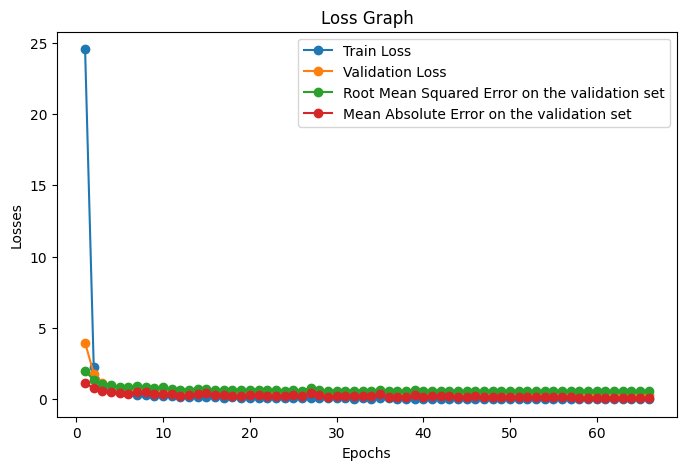

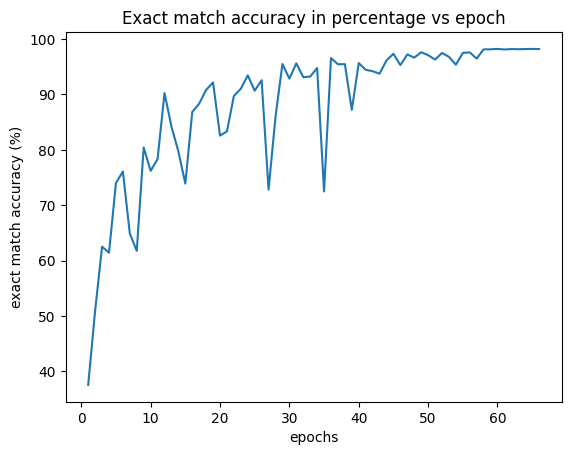

Reloaded best validation checkpoint from epoch 65


In [33]:
#it is normal for regression, we should normalize the datas and the rescale them, the important thing is that it is decreasing
cnn_baseline_best = train(
    model=expression_cnn_one_hot_model,
    x_train_data=x_train,
    y_train_data=y_train,
    optimizer=optimizer,
    loss_fn=loss_fn,
    normalized_coefficient=normalized_term,
    epochs=epochs,
    device=DEVICE,
    batch_size=batch_size,
    x_val_data=x_val,
    y_val_data=y_val,
    patience=20,
    min_delta=0.005,
)

In [34]:
print("Best CNN checkpoint:")
print("Epoch:", cnn_baseline_best["best_epoch"])
print("Validation accuracy:", cnn_baseline_best["best_model_accuracy"])
print("Validation loss:", cnn_baseline_best["best_model_loss"])
print("Validation RMSE:", cnn_baseline_best["best_model_RMSE"])
print("Validation MAE:", cnn_baseline_best["best_model_MAE"])

Best CNN checkpoint:
Epoch: 65
Validation accuracy: 98.225
Validation loss: 0.3021765947341919
Validation RMSE: 0.5497059226036072
Validation MAE: 0.08906771242618561


### 2.6 Training (Normalized Value)
By normalizing the outputs, the model should now train on a scaled version of the target values. This often leads to a more stable training process and potentially better convergence. The loss values reported will be for the normalized predictions. To get the actual predicted values, you would need to denormalize the model's output using (prediction * y_std) + y_mean. Given that the output usually is an integer we should also transform the data back into an integer.

After 40 epochs the errors and the validation loss are higher, but you can see that the training loss is actually decrasing, meaning that the optimization algorithm is working: we need to change architecture and tune hyperparameters

#### 2.6.1 Custom Loss Function for Exact Match Accuracy

To address the goal of improving 'exact match accuracy' while still benefiting from target normalization in a regression setup, we can define a custom loss function. This function will combine two main components:

1.  **Mean Squared Error (MSE)**: This is applied to the *normalized* predictions and *normalized* true values. This is the primary regression loss that helps the model learn the overall mapping from input to target, leveraging the stability and convergence benefits of normalization.

2.  **Exact Match Penalty (EMP)**: This term is designed to explicitly encourage the *denormalized* predictions to be very close to the *original integer targets*. The condition for an 'exact match' (after rounding) is that the denormalized prediction `y_pred_denormalized` must satisfy `y_true - 0.5 <= y_pred_denormalized < y_true + 0.5`, where `y_true` is the original integer target. This is equivalent to `|y_pred_denormalized - y_true| < 0.5`.

    Our EMP term will therefore penalize the model when `|y_pred_denormalized - y_true| >= 0.5`. By using `torch.clamp(abs_diff - 0.5, min=0)**2`, we create a differentiable penalty that is zero if the prediction is within 0.5 of the true value and grows quadratically if it's further away. This subtly guides the model towards making predictions that will round correctly, without relying on non-differentiable `torch.round` in the backpropagation.

    **Important Note**: The `y_true_normalized` value is denormalized to recover the original integer `y_true` value within this penalty calculation. Therefore, the `y_mean` and `y_std` values from your normalization step are crucial for this part of the loss function.

We will define this as a `torch.nn.Module` subclass, making it easy to integrate into the training loop.

In [35]:
class CustomExactMatchLoss(nn.Module):
    def __init__(self, y_mean, y_std, alpha=1.0, beta=0.01, margin=0.5):
        super().__init__()
        self.y_mean = y_mean
        self.y_std = y_std
        self.alpha = alpha
        self.beta = beta
        self.margin = margin
        self.mse_loss_fn = nn.MSELoss(reduction='mean')

    def forward(self, y_pred_normalized, y_true_normalized):
        # 1. MSE component on normalized values
        mse_normalized_loss = self.mse_loss_fn(y_pred_normalized, y_true_normalized)

        # 2. Exact Match Penalty (EMP) component on denormalized values
        # Denormalize predictions and true values
        y_pred_denormalized = y_pred_normalized * self.y_std + self.y_mean
        y_true_denormalized = y_true_normalized * self.y_std + self.y_mean # This recovers the original integer y_true

        # EMP term: penalizes when |y_pred_denormalized - y_true_denormalized| >= 0.5
        # This means the prediction would round to an incorrect integer.
        abs_diff_denormalized = torch.abs(y_pred_denormalized - y_true_denormalized)
        emp_term = torch.clamp(abs_diff_denormalized - self.margin,min=0) # Zero if |diff| < 0.5, positive otherwise
        emp_loss = torch.mean(emp_term ** 2) # Penalize quadratically

        # Combine the two loss components
        return self.alpha * mse_normalized_loss + self.beta * emp_loss


In [36]:
y_train_normalized = combined_train_df["normalized_value"]
y_val_normalized = combined_validation_df["normalized_value"]

In [37]:
expression_cnn_one_hot_model_normal = ExpressionCNNOneHot(
    vocab_size=VOCAB_SIZE,
    hidden_channels=128,
    num_outputs=1
)


[0.001]

--- Epoch 1 ---
Train Loss: 0.22677045
Validation Loss: 1.0296
RMSE Loss on the validation set: 1.0147
MAE Loss on the validation set: 0.5806
Correct predictions on the validation set: 2260 / 4000 (56.50%)


[0.001]

--- Epoch 2 ---
Train Loss: 0.00680715
Validation Loss: 0.6921
RMSE Loss on the validation set: 0.8319
MAE Loss on the validation set: 0.4288
Correct predictions on the validation set: 2846 / 4000 (71.15%)


[0.001]

--- Epoch 3 ---
Train Loss: 0.00462374
Validation Loss: 0.5014
RMSE Loss on the validation set: 0.7081
MAE Loss on the validation set: 0.2713
Correct predictions on the validation set: 3517 / 4000 (87.92%)


[0.001]

--- Epoch 4 ---
Train Loss: 0.00343495
Validation Loss: 0.5497
RMSE Loss on the validation set: 0.7414
MAE Loss on the validation set: 0.3326
Correct predictions on the validation set: 3218 / 4000 (80.45%)


[0.001]

--- Epoch 5 ---
Train Loss: 0.00266522
Validation Loss: 0.6773
RMSE Loss on the validation set: 0.8230
MAE Loss on the val

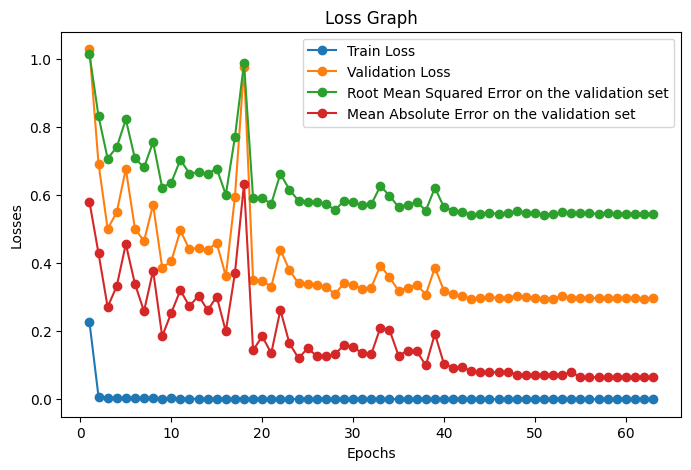

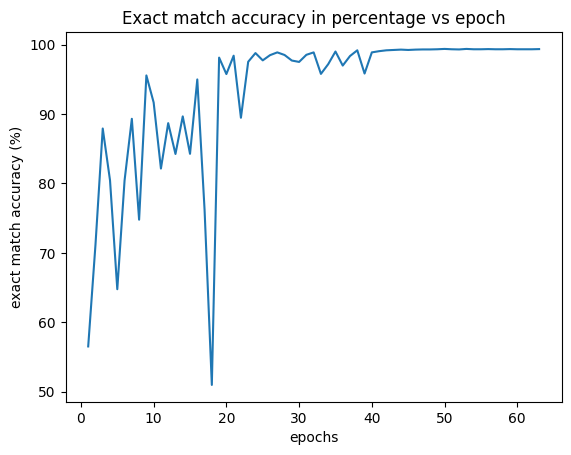

Reloaded best validation checkpoint from epoch 43


In [38]:
# Reset optimizer as model has been re-instantiated
optimizer_normal = torch.optim.Adam(expression_cnn_one_hot_model_normal.parameters(), lr=learning_rate)
normalized_training = True
loss_fn_normalized = CustomExactMatchLoss(y_mean=y_mean,  y_std=y_std, alpha=1.0, beta=0.01, margin=0.5)

cnn_custom_loss_best = train(
    model=expression_cnn_one_hot_model_normal,
    x_train_data=x_train,
    y_train_data=y_train_normalized,
    optimizer=optimizer_normal,
    loss_fn=loss_fn_normalized,
    normalized_coefficient=normalized_term,
    epochs=epochs,
    device=DEVICE,
    batch_size=batch_size,
    normalized_training=normalized_training,
    x_val_data=x_val,
    y_val_data=y_val_normalized,
    patience=20,
    min_delta=0.005,
)

In [39]:
print("Best CNN custom loss checkpoint:")
print("Epoch:", cnn_custom_loss_best["best_epoch"])
print("Validation accuracy:", cnn_custom_loss_best["best_model_accuracy"])
print("Validation loss:", cnn_custom_loss_best["best_model_loss"])
print("Validation RMSE:", cnn_custom_loss_best["best_model_RMSE"])
print("Validation MAE:", cnn_custom_loss_best["best_model_MAE"])

Best CNN custom loss checkpoint:
Epoch: 43
Validation accuracy: 99.25
Validation loss: 0.2945110499858856
Validation RMSE: 0.5426887273788452
Validation MAE: 0.08344285935163498


###2.7 Testing the Regressors

In [40]:
model_baseline_eval = ExpressionCNNOneHot(vocab_size=VOCAB_SIZE, hidden_channels=128, num_outputs=1)
model_baseline_eval.load_state_dict(cnn_baseline_best["best_model_state"])

# Create DataLoader for each test set
test_id_dataset = list(zip(test_id_df["expression"], test_id_df["value"]))
test_id_loader = torch.utils.data.DataLoader(test_id_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

test_ood_dataset = list(zip(test_ood_df["expression"], test_ood_df["value"]))
test_ood_loader = torch.utils.data.DataLoader(test_ood_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

test_long_dataset = list(zip(test_long_df["expression"], test_long_df["value"]))
test_long_loader = torch.utils.data.DataLoader(test_long_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Evaluate using the created DataLoaders
_, RMSE_id, MAE_id, correct_id = evaluate(model_baseline_eval, test_id_loader, DEVICE, normalized_training = False)
_, RMSE_ood, MAE_ood, correct_ood = evaluate(model_baseline_eval, test_ood_loader, DEVICE, normalized_training = False)
_, RMSE_long, MAE_long, correct_long = evaluate(model_baseline_eval, test_long_loader, DEVICE, normalized_training = False)

print(f"Test ID RMSE: {RMSE_id:.4f}, MAE: {MAE_id:.4f}, Correct Matches: {correct_id}")
print(f"Test OOD RMSE: {RMSE_ood:.4f}, MAE: {MAE_ood:.4f}, Correct Matches: {correct_ood}")
print(f"Test Long RMSE: {RMSE_long:.4f}, MAE: {MAE_long:.4f}, Correct Matches: {correct_long} ({correct_long/len(test_long_df['expression']) * 100} %)")

Test ID RMSE: 0.3007, MAE: 0.1129, Correct Matches: 1938
Test OOD RMSE: 1.2237, MAE: 0.4859, Correct Matches: 1571
Test Long RMSE: 3.2606, MAE: 1.9484, Correct Matches: 459 (30.599999999999998 %)


In [41]:
model_normal_eval = ExpressionCNNOneHot(vocab_size=VOCAB_SIZE, hidden_channels=128, num_outputs=1)
model_normal_eval.load_state_dict(cnn_custom_loss_best["best_model_state"])



# Create DataLoader for each test set
test_id_dataset = list(zip(test_id_df["expression"], test_id_df["normalized_value"]))
test_id_loader = torch.utils.data.DataLoader(test_id_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

test_ood_dataset = list(zip(test_ood_df["expression"], test_ood_df["normalized_value"]))
test_ood_loader = torch.utils.data.DataLoader(test_ood_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

test_long_dataset = list(zip(test_long_df["expression"], test_long_df["normalized_value"]))
test_long_loader = torch.utils.data.DataLoader(test_long_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# Evaluate using the created DataLoaders
_, RMSE_id, MAE_id, correct_id = evaluate(model_normal_eval, test_id_loader, DEVICE, normalized_training = True)
_, RMSE_ood, MAE_ood, correct_ood = evaluate(model_normal_eval, test_ood_loader, DEVICE, normalized_training = True)
_, RMSE_long, MAE_long, correct_long = evaluate(model_normal_eval, test_long_loader, DEVICE, normalized_training = True)

print(f"Test ID RMSE: {RMSE_id:.4f}, MAE: {MAE_id:.4f}, Correct Matches: {correct_id}")
print(f"Test OOD RMSE: {RMSE_ood:.4f}, MAE: {MAE_ood:.4f}, Correct Matches: {correct_ood}")
print(f"Test Long RMSE: {RMSE_long:.4f}, MAE: {MAE_long:.4f}, Correct Matches: {correct_long} ({correct_long/len(test_long_df['expression']) * 100} %)")

Test ID RMSE: 0.1272, MAE: 0.0786, Correct Matches: 1986
Test OOD RMSE: 0.9226, MAE: 0.3408, Correct Matches: 1702
Test Long RMSE: 2.7105, MAE: 1.5283, Correct Matches: 592 (39.46666666666667 %)


# 3. Saving Model

### Saving the CNN checkpoint

Kok’s original save function is kept commented below as reference.  
I slightly extended it because saving only the model weights is usually not enough if we want to load the CNN in another notebook.

When we reload the model somewhere else, we need to rebuild it with exactly the same settings used during training: same vocabulary size, same token mapping, same padding token, same model architecture, and same target normalization values.  
If any of these are missing or different, the model might either fail to load or, even worse, load successfully but produce inconsistent predictions.

For this reason, this checkpoint saves not only `model.state_dict()`, but also:
- the optimizer state, so training can be resumed if needed;
- the epoch number;
- the validation loss / metrics;
- the model configuration;
- the vocabulary and token-to-index mapping;
- the padding token;
- the normalization values used for the target variable.

Also, since we noticed possible overfitting, the idea is to save the **best validation checkpoint**, not necessarily the final epoch.  
The final epoch can have a lower training loss, but worse validation performance. Saving the best validation model should make the file more reliable for later testing or for loading it into another notebook.

In [42]:
#def save_checkpoint(model, optimizer, epoch, path, loss=None):
    # Ensure folder exists
    #directory = os.path.dirname(path)
    #os.makedirs(directory, exist_ok=True)

    # Build checkpoint dictionary
    #checkpoint = {
        #"model_state": model.state_dict(),
       # "optimizer_state": optimizer.state_dict(),
       # "epoch": epoch
   # }

    # optional field
   # if loss is not None:
     #   checkpoint["loss"] = loss

    # Save
   # torch.save(checkpoint, path)

   # print(f"Checkpoint saved to: {path}")

def save_checkpoint(model, optimizer, epoch, path, loss=None, extra=None):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    checkpoint = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "epoch": epoch,
        "loss": loss,
        "model_config": {
            "vocab_size": VOCAB_SIZE,
            "hidden_channels": 128,
            "num_outputs": 1,
        },
        "token_to_index": token_to_index,
        "V": V,
        "pad_token": PAD_TOKEN,
        "y_mean": float(y_mean),
        "y_std": float(y_std),
    }

    if extra is not None:
        checkpoint.update(extra)

    torch.save(checkpoint, path)
    print(f"Checkpoint saved to: {path}")


def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location=device)

    model = ExpressionCNNOneHot(**checkpoint["model_config"]).to(device)
    model.load_state_dict(checkpoint["model_state"])
    model.eval()

    print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
    return model, checkpoint

### Loading the CNN checkpoint

This function is meant to load the trained CNN in another notebook without manually guessing the original setup.

The checkpoint contains both the trained weights and the information needed to reconstruct the model correctly.  
So instead of manually creating a new CNN and hoping that all hyperparameters match, we read the saved `model_config` from the checkpoint and rebuild the model from that.

The function also uses `map_location=device`, so the checkpoint can be loaded safely even if it was trained on GPU and later loaded on CPU, or vice versa.

After loading the weights, the model is set to `eval()` mode because this is the mode we want when using the saved model for validation, test predictions, or final evaluation. This is especially important if the architecture uses layers like dropout or batch normalization.

The function returns both:
- the reconstructed model, ready to use for predictions;
- the checkpoint dictionary, which still contains extra information such as epoch, validation metrics, vocabulary, padding token, and normalization values.

In [43]:
#def load_checkpoint(model, optimizer, path):
    #checkpoint = torch.load(path)

    #model.load_state_dict(checkpoint["model_state"])
    #optimizer.load_state_dict(checkpoint["optimizer_state"])

    #epoch = checkpoint["epoch"]

    #print(f"Loaded checkpoint from epoch {epoch}")
    #return model, optimizer, epoch



# After the training
model_to_save = expression_cnn_one_hot_model_normal
model_to_save.load_state_dict(cnn_custom_loss_best["best_model_state"])

save_checkpoint(
    model=model_to_save,
    optimizer=optimizer_normal,
    epoch=cnn_custom_loss_best["best_epoch"],
    path="/content/cnn_regressor_best.pt",
    loss=cnn_custom_loss_best["best_model_loss"],
    extra={
        "val_accuracy": cnn_custom_loss_best["best_model_accuracy"],
        "val_rmse": cnn_custom_loss_best["best_model_RMSE"],
        "val_mae": cnn_custom_loss_best["best_model_MAE"],
        "normalized_training": True,
    }
)

loaded_model, loaded_checkpoint = load_checkpoint(
    "/content/cnn_regressor_best.pt",
    DEVICE
)

print(loaded_checkpoint.keys())


Checkpoint saved to: /content/cnn_regressor_best.pt
Loaded checkpoint from epoch 43
dict_keys(['model_state', 'optimizer_state', 'epoch', 'loss', 'model_config', 'token_to_index', 'V', 'pad_token', 'y_mean', 'y_std', 'val_accuracy', 'val_rmse', 'val_mae', 'normalized_training'])


#Some tests

In [44]:
# Evaluate the selected normalized CNN on the training set.
# This is useful to compare training MAE and validation MAE on the same scale.
# The training loss during optimization is computed on normalized targets with the custom loss,
# so it is not directly comparable with validation MAE.
# Here we compute MAE/RMSE after denormalization, exactly like we do for validation and test.

train_eval_dataset = list(zip(x_train, y_train_normalized))

train_eval_loader = torch.utils.data.DataLoader(
    train_eval_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

train_loss_eval, train_rmse_eval, train_mae_eval, train_correct_eval = evaluate(
    expression_cnn_one_hot_model_normal,
    train_eval_loader,
    DEVICE,
    normalized_training=True
)

train_accuracy_eval = train_correct_eval / len(train_eval_dataset) * 100

print("Normalized CNN - Training set evaluation")
print("Train RMSE:", train_rmse_eval.item())
print("Train MAE:", train_mae_eval.item())
print("Train exact-match accuracy:", train_accuracy_eval)

Normalized CNN - Training set evaluation
Train RMSE: 0.06496994197368622
Train MAE: 0.048400480300188065
Train exact-match accuracy: 99.99166666666667


In [45]:
print("Best validation RMSE:", cnn_custom_loss_best["best_model_RMSE"])
print("Best validation MAE:", cnn_custom_loss_best["best_model_MAE"])
print("Best validation accuracy:", cnn_custom_loss_best["best_model_accuracy"])

Best validation RMSE: 0.5426887273788452
Best validation MAE: 0.08344285935163498
Best validation accuracy: 99.25
